In [1]:
# Importing Libraries
import ast
import pandas as pd
from datasets import load_dataset
import matplotlib.pyplot as plt  
import seaborn as sns

# Loading Data
dataset = load_dataset('lukebarousse/data_jobs')
df = dataset['train'].to_pandas()

# Data Cleanup
df['job_posted_date'] = pd.to_datetime(df['job_posted_date'])

# # Convert string representation to actual list, checking for NaN values first
df['job_skills' ] = df['job_skills'].apply(lambda x: ast.literal_eval(x) if pd.notna(x) else x)

/opt/anaconda3/envs/python_course/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
df_DA_UK = df[(df['job_title'] == 'Data Analyst') & (df['job_country'] == 'United Kingdom')].copy()

In [3]:
df_DA_UK = df_DA_UK.dropna(subset=['salary_year_avg'])

df_DA_UK_expoded = df_DA_UK.explode('job_skills')

df_DA_UK_expoded[['salary_year_avg', 'job_skills']].head(5)

,salary_year_avg,job_skills
25994,105000.0,go
25994,105000.0,gdpr
25994,105000.0,dax
84680,105000.0,sql
98784,100500.0,sql


In [4]:
df_DA_skills =df_DA_UK_expoded.groupby('job_skills')['salary_year_avg'].agg(['count', 'mean']).sort_values('count', ascending=False)

df_DA_skills = df_DA_skills.rename(columns={'count': 'skill_count', 'mean': 'median_salary'})

DA_job_cont = len(df_DA_UK)

df_DA_skills['skill_percent'] = (df_DA_skills['skill_count'] / DA_job_cont) * 100

skill_percent = 10

df_DA_skills_in_hight_demand = df_DA_skills[df_DA_skills['skill_percent'] > skill_percent]

df_DA_skills_in_hight_demand



,skill_count,median_salary,skill_percent
job_skills,,,
sql,10,81654.550,62.50
excel,5,87700.000,31.25
python,4,86511.375,25.00
tableau,4,82375.000,25.00
sas,2,51014.000,12.50


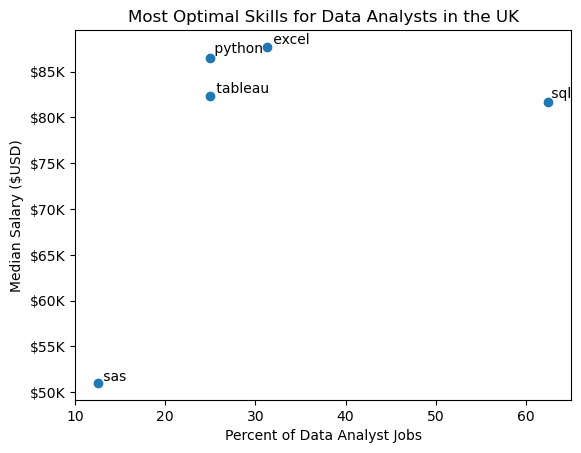

In [5]:
from adjustText import adjust_text

plt.scatter(df_DA_skills_in_hight_demand['skill_percent'], df_DA_skills_in_hight_demand['median_salary'])
plt.xlabel('Percent of Data Analyst Jobs')
plt.ylabel('Median Salary ($USD)')  # Assuming this is the label you want for y-axis
plt.title('Most Optimal Skills for Data Analysts in the UK')

# Get current axes, set limits, and format axes
ax = plt.gca()
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, pos: f'${int(y/1000)}K'))  # Example formatting y-axis

# Add labels to points and collect them in a list
texts = []
for i, txt in enumerate(df_DA_skills_in_hight_demand.index):
    texts.append(plt.text(df_DA_skills_in_hight_demand['skill_percent'].iloc[i], df_DA_skills_in_hight_demand['median_salary'].iloc[i], " " + txt))

# Adjust text to avoid overlap and add arrows
adjust_text(texts, arrowprops=dict(arrowstyle='->', color='gray'))

plt.show()

In [6]:
df_technology = df['job_type_skills'].copy()

# remove duplicates
df_technology = df_technology.drop_duplicates()

# remove NaN values
df_technology = df_technology.dropna()

# combine all dictionaries into one
technology_dict = {}
for row in df_technology:
    row_dict = ast.literal_eval(row)  # convert string to dictionary
    for key, value in row_dict.items():
        if key in technology_dict:  # if key already exists in technology_dict, add value to existing value
            technology_dict[key] += value
        else:                       # if key does not exist in technology_dict, add key and value
            technology_dict[key] = value

# remove duplicates by converting values to set then back to list
for key, value in technology_dict.items():
    technology_dict[key] = list(set(value))

technology_dict

{'analyst_tools': ['ssis',
  'outlook',
  'powerpoint',
  'ms access',
  'datarobot',
  'msaccess',
  'esquisse',
  'dax',
  'ssrs',
  'qlik',
  'looker',
  'cognos',
  'sheets',
  'spreadsheet',
  'splunk',
  'power bi',
  'nuix',
  'powerbi',
  'spss',
  'visio',
  'sap',
  'sharepoint',
  'sas',
  'word',
  'microstrategy',
  'alteryx',
  'tableau',
  'excel'],
 'programming': ['ocaml',
  'delphi',
  'powershell',
  'apl',
  'visual basic',
  'matlab',
  'swift',
  'clojure',
  'mongodb',
  'perl',
  'sql',
  'crystal',
  'dart',
  'c#',
  'java',
  'go',
  't-sql',
  'bash',
  'c',
  'objective-c',
  'scala',
  'vb.net',
  'cobol',
  'pascal',
  'css',
  'vba',
  'golang',
  'r',
  'fortran',
  'visualbasic',
  'kotlin',
  'mongo',
  'f#',
  'elixir',
  'julia',
  'lua',
  'php',
  'ruby',
  'sas',
  'rust',
  'typescript',
  'javascript',
  'lisp',
  'sass',
  'html',
  'c++',
  'solidity',
  'haskell',
  'no-sql',
  'python',
  'groovy',
  'erlang',
  'nosql',
  'shell',
  'assem

In [7]:
df_technology = pd.DataFrame(list(technology_dict.items()), columns=['technology', 'skills'])

df_technology = df_technology.explode('skills')

df_technology

,technology,skills
0,analyst_tools,ssis
0,analyst_tools,outlook
0,analyst_tools,powerpoint
0,analyst_tools,ms access
0,analyst_tools,datarobot
...,...,...
9,sync,rocketchat
9,sync,twilio
9,sync,wire
9,sync,unify


In [15]:
df_DA_skills_tech = df_DA_skills.merge(df_technology, left_on='job_skills', right_on='skills')

In [17]:
df_DA_skills_in_hight_demand.columns
df_DA_skills_in_hight_demand.head()

,skill_count,median_salary,skill_percent
job_skills,,,
sql,10,81654.550,62.50
excel,5,87700.000,31.25
python,4,86511.375,25.00
tableau,4,82375.000,25.00
sas,2,51014.000,12.50


In [21]:
df_plot = df_DA_skills_in_hight_demand.reset_index()


df_DA_skills_tech_high_demand = df_DA_skills_tech[df_DA_skills_tech['skill_percent'] > skill_percent]

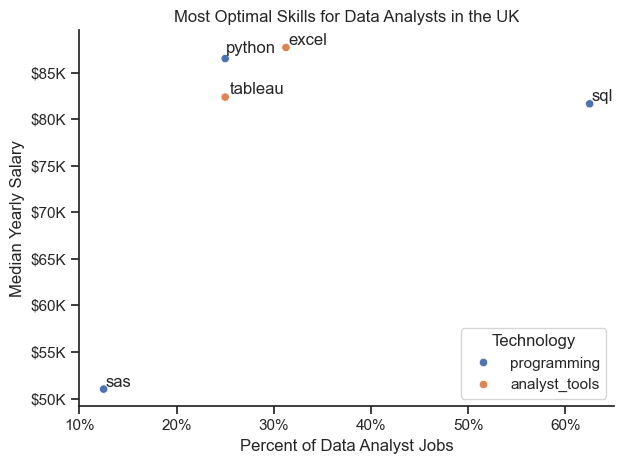

In [30]:
sns.scatterplot(
    data=df_DA_skills_tech_high_demand,
    x="skill_percent",
    y="median_salary",
    hue="technology")

sns.despine()
sns.set_theme(style='ticks')

# Prepare texts for adjustText
texts = []
for i, txt in enumerate(df_DA_skills_in_hight_demand.index):
    texts.append(plt.text(df_DA_skills_in_hight_demand['skill_percent'].iloc[i], df_DA_skills_in_hight_demand['median_salary'].iloc[i], txt))

# Adjust text to avoid overlap
adjust_text(texts, arrowprops=dict(arrowstyle='->', color='gray'))

# Set axis labels, title, and legend
plt.xlabel('Percent of Data Analyst Jobs')
plt.ylabel('Median Yearly Salary')
plt.title('Most Optimal Skills for Data Analysts in the UK')
plt.legend(title='Technology')

from matplotlib.ticker import PercentFormatter
ax = plt.gca()
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, pos: f'${int(y/1000)}K'))
ax.xaxis.set_major_formatter(PercentFormatter(decimals=0))

# Adjust layout and display plot 
plt.tight_layout()
plt.show()